In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

## Load data:

In [3]:
# fp_proc_moth_data = '/Users/tplas/data/2025-06-16 moth data Natalie/1994-2019_field-d50.csv'
fp_proc_moth_data = '/Users/tplas/data/2025-10-07 moth raw data 2023/Qry_D50_AllClutches_CommonGarden.xlsx'
assert os.path.exists(fp_proc_moth_data)

if fp_proc_moth_data.endswith('.csv'):
    df_proc = pd.read_csv(fp_proc_moth_data, sep=';')
elif fp_proc_moth_data.endswith('.xlsx'):
    df_proc = pd.read_excel(fp_proc_moth_data)
df_proc

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,D50Calc
0,1994,1995,HV,98,4,15,5944,CG1995,15.0
1,1994,1995,HV,98,44,15,5946,CG1995,8.0
2,1994,1995,HV,98,11,15,5947,CG1995,1.0
3,1994,1995,HV,98,41,15,5949,CG1995,8.0
4,1994,1995,HV,98,41,15,5950,CG1995,8.0
...,...,...,...,...,...,...,...,...,...
7392,2024,2025,WA,1,1,25,21382,CG2025,4.2
7393,2024,2025,WA,1,1,21,21383,CG2025,6.0
7394,2024,2025,WA,2,2,28,21385,CG2025,7.8
7395,2024,2025,WA,2,10,42,21386,CG2025,9.9


In [4]:
fp_raw_moth_data = '/Users/tplas/data/2025-10-07 moth raw data 2023/Qry_NumberOfCaterpillarsPerClutchPerDay.txt'
assert os.path.exists(fp_raw_moth_data)

## read as csv 
df_raw = pd.read_csv(fp_raw_moth_data, sep=';')
df_raw

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,AprilDay,Caterpillars
0,1994,1995,HV,98,4,15,5944,CG1995,-14,0.0
1,1994,1995,HV,98,4,15,5944,CG1995,-1,0.0
2,1994,1995,HV,98,4,15,5944,CG1995,5,0.0
3,1994,1995,HV,98,4,15,5944,CG1995,11,0.0
4,1994,1995,HV,98,4,15,5944,CG1995,19,30.0
...,...,...,...,...,...,...,...,...,...,...
119003,2024,2025,WA,2,12,25,21400,CG2025,10,6.0
119004,2024,2025,WA,2,12,25,21400,CG2025,16,8.0
119005,2024,2025,WA,2,12,25,21400,CG2025,17,1.0
119006,2024,2025,WA,2,12,25,21400,CG2025,22,0.0


## Re-calculate D50 for the raw data:

In [5]:
def add_relative_caterpillar_counts(df, remove_zero_tubes=True, min_num_caterpillars=10):
    df = df.copy()
    ## Add total caterpillars per tube:
    df_cp_per_tube = df.groupby(['TubeID']).agg({'Caterpillars':'sum'}).reset_index()
    df['TotalCaterpillarsPerTube'] = df['TubeID'].map(df_cp_per_tube.set_index('TubeID')['Caterpillars'])
    if remove_zero_tubes:
        df = df[df['TotalCaterpillarsPerTube'] > 0]
    if min_num_caterpillars is not None:
        df = df[df['TotalCaterpillarsPerTube'] >= min_num_caterpillars]

    ## Add (cumulative) relative caterpillar counts per tube:
    df['RelativeCaterpillarsPerTube'] = df['Caterpillars'] / df['TotalCaterpillarsPerTube']
    df['CumulativeRelativeCaterpillarsPerTube'] = df.groupby('TubeID')['RelativeCaterpillarsPerTube'].cumsum()
    return df 

df_raw = add_relative_caterpillar_counts(df_raw)
print(f"Number of unique tubes in raw data: {df_raw.TubeID.nunique()}")

Number of unique tubes in raw data: 7277


In [6]:
def calculate_d50(df, column='Caterpillars', verbose=0):
    assert 'TubeID' in df.columns and column in df.columns and 'AprilDay' in df.columns
    max_cp = int(df[column].max())
    if max_cp == 0.0:
        if verbose:
            print("WARNING: max_cp is 0.0"
                  f" for TubeID {df.TubeID.values[0]}")
        return np.nan
    
    if column == 'RelativeCaterpillarsPerTube':
        half_cp = 0.5
        max_cp = 1.0
    else:
        half_cp = max_cp / 2

    ## get the first day where the caterpillars are above half_cp
    df_half_top = df[df[column] >= half_cp]
    day_top = df_half_top.AprilDay.min()
    count_top = df_half_top[df_half_top.AprilDay == day_top][column].values[0]
    # count_top = df_half_top[column].min()
    # day_top = df_half_top[df_half_top[column] == count_top].AprilDay.values[0]

    ## get the last day where the caterpillars are below half_cp
    df_half_bottom = df[df[column] <= half_cp]
    if df_half_bottom.shape[0] == 0 or df_half_bottom[column].max() == 0.0:
        if verbose:
            print("WARNING: no bottom half found"
                f" for TubeID {df.TubeID.values[0]} with max_cp {max_cp}")
        return np.nan
    else:
        count_bottom = df_half_bottom[column].max()
        day_bottom = df_half_bottom[df_half_bottom[column] == count_bottom].AprilDay.values[0]

    if verbose:
        print(f"TubeID {df.TubeID.values[0]}: max_cp {max_cp}, half_cp {half_cp}, "
              f"day_bottom {day_bottom} (count_bottom {count_bottom}), "
              f"day_top {day_top} (count_top {count_top})")
        
    if count_top == count_bottom:
        if verbose:
            print(f"count_top == count_bottom for TubeID {df.TubeID.values[0]} with max_cp {max_cp}")
        return day_top
    
    # linear interpolation to find the day where the count is exactly half_cp
    d50 = day_bottom + (half_cp - count_bottom) * (day_top - day_bottom) / (count_top - count_bottom)
    return float(d50)

In [7]:
df_proc['RecalculatedD50'] = np.nan 
for i, row in df_proc.iterrows():
    tube_id = row['TubeID']
    if tube_id in df_raw.TubeID.values:
        d50_calc = calculate_d50(df_raw[df_raw.TubeID == tube_id], 
                                 column='CumulativeRelativeCaterpillarsPerTube', verbose=0)
        df_proc.at[i, 'RecalculatedD50'] = d50_calc

df_proc

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,D50Calc,RecalculatedD50
0,1994,1995,HV,98,4,15,5944,CG1995,15.0,NaN
1,1994,1995,HV,98,44,15,5946,CG1995,8.0,NaN
2,1994,1995,HV,98,11,15,5947,CG1995,1.0,1.000000
3,1994,1995,HV,98,41,15,5949,CG1995,8.0,NaN
4,1994,1995,HV,98,41,15,5950,CG1995,8.0,NaN
...,...,...,...,...,...,...,...,...,...,...
7392,2024,2025,WA,1,1,25,21382,CG2025,4.2,4.156863
7393,2024,2025,WA,1,1,21,21383,CG2025,6.0,5.980198
7394,2024,2025,WA,2,2,28,21385,CG2025,7.8,7.757576
7395,2024,2025,WA,2,10,42,21386,CG2025,9.9,9.933333


In [8]:
unique_tubes_raw_data = df_raw.TubeID.unique()
unique_tubes_proc_data = df_proc.TubeID.unique()

raw_tubes_not_in_proc = [tube for tube in unique_tubes_raw_data if tube not in unique_tubes_proc_data]
proc_tubes_not_in_raw = [tube for tube in unique_tubes_proc_data if tube not in unique_tubes_raw_data]

print(f"Tubes in raw data but not in processed data: {len(raw_tubes_not_in_proc)}, tubes in processed data but not in raw data: {len(proc_tubes_not_in_raw)}")

Tubes in raw data but not in processed data: 33, tubes in processed data but not in raw data: 0


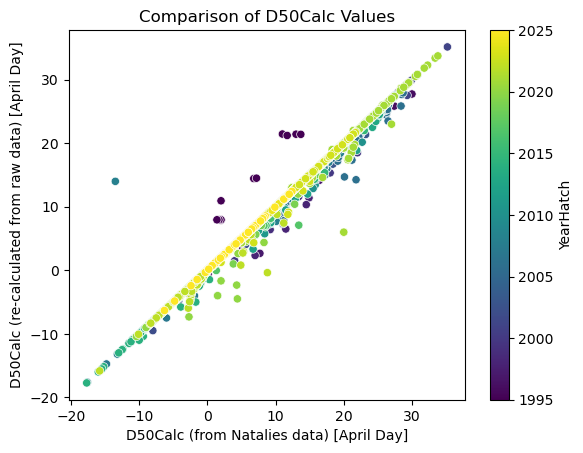

In [20]:
import matplotlib as mpl
cmap= sns.color_palette('viridis', as_cmap= True)
sm = plt.cm.ScalarMappable(cmap= cmap, norm=mpl.colors.Normalize())
sns.scatterplot(data=df_proc, x='D50Calc', y='RecalculatedD50', 
                hue='YearHatch', hue_norm=sm.norm, palette=cmap, legend=False)
                # hue='YearHatch', palette='viridis', alpha=0.7)
plt.xlabel('D50Calc (from Natalies data) [April Day]')
plt.ylabel('D50Calc (re-calculated from raw data) [April Day]')
plt.title('Comparison of D50Calc Values')
cbar = plt.colorbar(sm, ax = plt.gca(), label='YearHatch')


## Example tubes:

In [24]:
## Print all mismatched tubes:
mismatched_tubes = df_proc[np.abs(df_proc.D50Calc - df_proc.RecalculatedD50) > 1]
mismatched_tubes

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,D50Calc,RecalculatedD50
8,1994,1995,HV,98,48,15,5956,CG1995,2.0,7.909910
9,1994,1995,HV,98,41,18,5969,CG1995,11.0,21.449950
10,1994,1995,HV,98,41,18,5970,CG1995,13.0,21.424925
11,1994,1995,HV,98,41,18,5971,CG1995,11.7,21.224725
12,1994,1995,HV,98,41,18,5972,CG1995,13.7,21.399900
...,...,...,...,...,...,...,...,...,...,...
6830,2021,2022,OH,6,9,29,19050,CG2022,-2.3,-3.306306
7017,2022,2023,OH,2,9,21,19427,CG2023,6.8,4.333333
7088,2022,2023,OH,4,1,42,19564,CG2023,14.0,12.500000
7135,2022,2023,OH,5,2,35,19642,CG2023,11.9,9.137931


In [29]:
## Look at raw data for a specific tube:
tube_id = 5956

d50_original = df_proc[df_proc.TubeID == tube_id].D50Calc.values[0]
d50_recalculated = calculate_d50(df_raw[df_raw.TubeID == tube_id], column='CumulativeRelativeCaterpillarsPerTube', verbose=1)
print(f"\nOriginal D50 for TubeID {tube_id}: {np.round(d50_original, 2)}\nRe-calculated D50 for TubeID {tube_id}: {np.round(d50_recalculated, 2)}")


df_raw[df_raw.TubeID == tube_id]

TubeID 5956: max_cp 1, half_cp 0.5, day_bottom 5 (count_bottom 0.029154518950437316), day_top 11 (count_top 1.0)

Original D50 for TubeID 5956: 2.0
Re-calculated D50 for TubeID 5956: 7.91


,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,AprilDay,Caterpillars,TotalCaterpillarsPerTube,RelativeCaterpillarsPerTube,CumulativeRelativeCaterpillarsPerTube
60,1994,1995,HV,98,48,15,5956,CG1995,-14,0.0,1029.0,0.000000,0.000000
61,1994,1995,HV,98,48,15,5956,CG1995,-1,0.0,1029.0,0.000000,0.000000
62,1994,1995,HV,98,48,15,5956,CG1995,5,30.0,1029.0,0.029155,0.029155
63,1994,1995,HV,98,48,15,5956,CG1995,11,999.0,1029.0,0.970845,1.000000
64,1994,1995,HV,98,48,15,5956,CG1995,19,0.0,1029.0,0.000000,1.000000
65,1994,1995,HV,98,48,15,5956,CG1995,24,0.0,1029.0,0.000000,1.000000
